## Simple Linear Regression only x = age and y = salary 

In [ ]:
import random
import matplotlib.pyplot as plt

x_age = [10, 20, 30, 40, 50, 60, 90]
y_salary = [200, 400, 600, 800, 1000, 1200, 400]


def split_data(x, y, test_ratio=0.3):

    total = len(x)
    test_size = int(total * test_ratio)
    train_size = total - test_size

    train_index = random.sample(range(total), train_size)

    x_train = []
    y_train = []

    for i in train_index:
        x_train.append(x[i])
        y_train.append(y[i])

    test_index = []
    for i in range(total):
        if i not in train_index:
            test_index.append(i)

    x_test = []
    y_test = []

    for i in test_index:
        x_test.append(x[i])
        y_test.append(y[i])

    print(train_index)
    print(test_index)

    return x_train, y_train, x_test, y_test


def train_model(x, y):

    n = len(x)

    sum_x = 0
    sum_y = 0
    sum_x2 = 0
    sum_xy = 0

    for i in range(n):
        sum_x += x[i]
        sum_y += y[i]
        sum_x2 += x[i] * x[i]
        sum_xy += x[i] * y[i]

    m = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x * sum_x)
    c = (sum_y - m * sum_x) / n

    return m, c


def predict(age):

    x_train, y_train, x_test, y_test = split_data(x_age, y_salary)

    m, c = train_model(x_train, y_train)

    print(m, c)

    plt.scatter(x_train, y_train)

    line = []
    for x in x_train:
        line.append(m * x + c)

    plt.plot(x_train, line)

    plt.xlabel("Age")
    plt.ylabel("Salary")
    plt.show()

    return m * age + c


print("Prediction:", predict(45))

[5, 4, 0, 1, 6]
[2, 3]


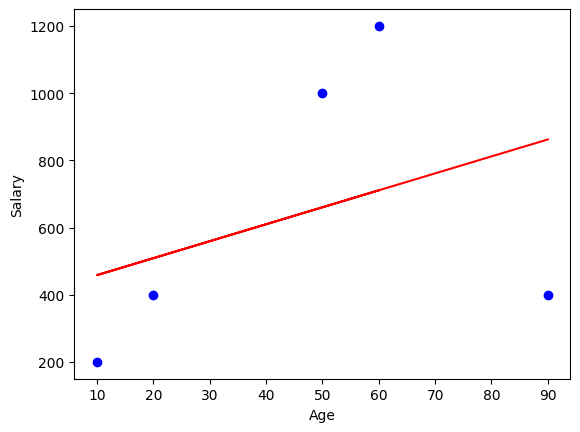

5.048543689320389 407.7669902912621


634.9514563106796

In [147]:
predict(45)

Epoch 0 | Loss: 215652.16
Epoch 100 | Loss: 150618.90
Epoch 200 | Loss: 149848.13
Epoch 300 | Loss: 149085.53
Epoch 400 | Loss: 148331.02
Epoch 500 | Loss: 147584.51
Epoch 600 | Loss: 146845.92
Epoch 700 | Loss: 146115.17
Epoch 800 | Loss: 145392.17
Epoch 900 | Loss: 144676.83
Final m, c: 9.998300522156248 27.42494716549778
Test MSE: 178876.42623762623
Prediction for age 45: 477.3484706625289


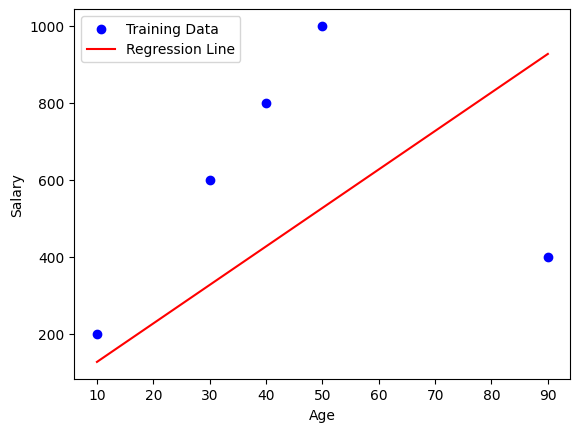

In [ ]:
import random
import matplotlib.pyplot as plt

x_age = [10, 20, 30, 40, 50, 60, 90]
y_salary = [200, 400, 600, 800, 1000, 1200, 400]


def split_data(x, y, test_ratio=0.3):

    total = len(x)
    test_size = int(total * test_ratio)
    train_size = total - test_size

    train_index = random.sample(range(total), train_size)

    x_train = []
    y_train = []

    for i in train_index:
        x_train.append(x[i])
        y_train.append(y[i])

    x_test = []
    y_test = []

    for i in range(total):
        if i not in train_index:
            x_test.append(x[i])
            y_test.append(y[i])

    return x_train, y_train, x_test, y_test


def gradient_descent(x, y, lr=0.0001, epochs=1000):

    m = 0
    c = 0
    n = len(x)

    for epoch in range(epochs):

        dm = 0
        dc = 0

        for i in range(n):
            y_pred = m * x[i] + c
            error = y[i] - y_pred

            dm += (-2/n) * x[i] * error
            dc += (-2/n) * error

        m = m - lr * dm
        c = c - lr * dc

        if epoch % 100 == 0:
            loss = 0
            for i in range(n):
                loss += (y[i] - (m * x[i] + c)) ** 2
            loss = loss / n
            print("Epoch", epoch, "| Loss:", round(loss, 2))

    return m, c


def mean_squared_error(x_test, y_test, m, c):

    total = 0

    for i in range(len(x_test)):
        total += (y_test[i] - (m * x_test[i] + c)) ** 2

    return total / len(x_test)


def predict(age, m, c):
    return m * age + c


x_train, y_train, x_test, y_test = split_data(x_age, y_salary)

m, c = gradient_descent(x_train, y_train)

print("Final m, c:", m, c)

mse = mean_squared_error(x_test, y_test, m, c)
print("Test MSE:", mse)

print("Prediction for age 45:", predict(45, m, c))




## MultiLinear Regression

In [149]:
# import random

# x_data = {'x1':[4,9,8,8,7,5],
#           'x2':[1,2,3,1,1,0],
#           'x3':[3,1,2,1,4,2]}


# y_data = [52,51,50,52,70,60]

# print(x_data['x1'])



# def random_split(x_data, y_data, test_size=0.2):

#     total_size = len(x_data['x1'])

#     test_size = int(total_size * test_size)
#     train_size = total_size - test_size

#     x_train_index = random.sample(range(total_size), train_size)

#     x_train = {}
#     for key in x_data:
#         x_train[key] = []
#         for i in x_train_index:
#             x_train[key].append(x_data[key][i])

#     y_train = []
#     for i in x_train_index:
#         y_train.append(y_data[i])

#     x_test_index = []
#     for i in range(total_size):
#         if i not in x_train_index:
#             x_test_index.append(i)

#     x_test = {}
#     for key in x_data:
#         x_test[key] = []
#         for i in x_test_index:
#             x_test[key].append(x_data[key][i])

#     y_test = []
#     for i in x_test_index:
#         y_test.append(y_data[i])

#     print(x_train_index)
#     print(x_test_index)

#     return x_train, y_train, x_test, y_test






In [150]:
# import matplotlib.pyplot as plt

# def multi_linear_regression(x_data, y_data):

#     x1_mean = sum(x_data['x1']) / len(x_data['x1'])
#     x2_mean = sum(x_data['x2']) / len(x_data['x2'])
#     x3_mean = sum(x_data['x3']) / len(x_data['x3'])
#     y_mean = sum(y_data) / len(y_data)

#     numerator_m1 = 0
#     denominator_m1 = 0

#     for i in range(len(y_data)):
#         numerator_m1 += (x_data['x1'][i] - x1_mean) * (y_data[i] - y_mean)
#         denominator_m1 += (x_data['x1'][i] - x1_mean) ** 2
#     m1 = numerator_m1 / denominator_m1

#     numerator_m2 = 0
#     denominator_m2 = 0
#     for i in range(len(y_data)):
#         numerator_m2 += (x_data['x2'][i] - x2_mean) * (y_data[i] - y_mean)
#         denominator_m2 += (x_data['x2'][i] - x2_mean) ** 2
#     m2 = numerator_m2 / denominator_m2

#     numerator_m3 = 0
#     denominator_m3 = 0
#     for i in range(len(y_data)):
#         numerator_m3 += (x_data['x3'][i] - x3_mean) * (y_data[i] - y_mean)
#         denominator_m3 += (x_data['x3'][i] - x3_mean) ** 2
#     m3 = numerator_m3 / denominator_m3

#     c = y_mean - (m1 * x1_mean + m2 * x2_mean + m3 * x3_mean)

#     return [m1, m2, m3], c


# def predict(x1, x2, x3):
#     x_train, y_train, x_test, y_test = random_split(x_data, y_data, test_size=0.5)
#     m, c = multi_linear_regression(x_train, y_train)

#     # plt.scatter(x_train['x1'] , x_train['x2'] , x_train['x3'], y_train, color='blue', label='Training Data')
#     plt.scatter(x_train['x1'] , y_train, color='blue', label='Training Data')
#     plt.plot(x_train['x1'], [m[0] * x + c for x in x_train['x1']], color='red', label='Regression Line')
    
#     plt.scatter(x_train['x2'] , y_train, color='blue', label='Training Data')
#     plt.plot(x_train['x2'], [m[0] * x + c for x in x_train['x2']], color='red', label='Regression Line')

#     plt.scatter(x_train['x3'] , y_train, color='blue', label='Training Data')
#     plt.plot(x_train['x3'], [m[0] * x + c for x in x_train['x3']], color='red', label='Regression Line')

#     plt.xlabel('X')
#     plt.ylabel('Y')
#     plt.title('Multi-Linear Regression')
   
#     plt.show()
#     print(m, c)
#     return m[0]*x1 + m[1]*x2 + m[2]*x3 + c

In [ ]:
import random
import numpy as np

x1 = [4, 9, 8, 8, 7, 5]
x2 = [1, 2, 3, 1, 1, 0]
x3 = [3, 1, 2, 1, 4, 2]

y = [52, 51, 50, 52, 70, 60]


def split_data(x1, x2, x3, y, test_ratio=0.3):

    total = len(y)
    train_size = int(total * (1 - test_ratio))

    train_index = random.sample(range(total), train_size)

    test_index = []
    for i in range(total):
        if i not in train_index:
            test_index.append(i)

    X_train = []
    y_train = []

    for i in train_index:
        row = [1, x1[i], x2[i], x3[i]]
        X_train.append(row)
        y_train.append(y[i])

    X_test = []
    y_test = []

    for i in test_index:
        row = [1, x1[i], x2[i], x3[i]]
        X_test.append(row)
        y_test.append(y[i])

    return X_train, y_train, X_test, y_test


def train_model(X_train, y_train):

    X = np.array(X_train)
    Y = np.array(y_train)

    XT = X.T
    XTX = np.dot(XT, X)
    XTX_inv = np.linalg.inv(XTX)
    XTY = np.dot(XT, Y)

    beta = np.dot(XTX_inv, XTY)
    
    
    # beta = np.zeros(features)
    # for _ in range(epochs):
    #     y_pred = np.dot(X, beta)
    #     error = y_pred - y
    #     gradient = (1/n) * np.dot(X.T, error)
    #     beta = beta - lr * gradient
    

    return beta


def test_model():

    X_train, y_train, X_test, y_test = split_data(x1, x2, x3, y)

    beta = train_model(X_train, y_train)

    print("Model coefficients (beta):", beta)

    X_test = np.array(X_test)

    y_pred = np.dot(X_test, beta)

    print("\nActual values:   ", y_test)
    print("Predicted values:", y_pred)


test_model()

Model coefficients (beta): [  0.  16. -32.  32.]

Actual values:    [52, 70]
Predicted values: [128. 208.]


In [200]:
import random
import numpy as np

x1 = [4, 9, 8, 8, 7, 5]
x2 = [1, 2, 3, 1, 1, 0]
x3 = [3, 1, 2, 1, 4, 2]

y = [52, 51, 50, 52, 70, 60]


def split_data(x1, x2, x3, y, test_ratio=0.3):

    total = len(y)
    train_size = int(total * (1 - test_ratio))

    train_index = random.sample(range(total), train_size)

    test_index = []
    for i in range(total):
        if i not in train_index:
            test_index.append(i)

    X_train = []
    y_train = []

    for i in train_index:
        row = [1, x1[i], x2[i], x3[i]]
        X_train.append(row)
        y_train.append(y[i])

    X_test = []
    y_test = []

    for i in test_index:
        row = [1, x1[i], x2[i], x3[i]]
        X_test.append(row)
        y_test.append(y[i])

    return X_train, y_train, X_test, y_test


def train_gradient_descent(X_train, y_train, lr=0.0001, epochs=1000):

    X = np.array(X_train)
    y = np.array(y_train)

    n, features = X.shape

    beta = np.zeros(features)

    for _ in range(epochs):

        y_pred = np.dot(X, beta)

        error = y_pred - y

        gradient = (1/n) * np.dot(X.T, error)

        beta = beta - lr * gradient

    return beta


def test_model():

    X_train, y_train, X_test, y_test = split_data(x1, x2, x3, y)

    beta = train_gradient_descent(X_train, y_train)

    print("Model coefficients (beta):", beta)

    X_test = np.array(X_test)

    y_pred = np.dot(X_test, beta)

    print("\nActual values:   ", y_test)
    print("Predicted values:", y_pred)


test_model()

Model coefficients (beta): [1.11300328 6.29497356 1.02623504 3.64870409]

Actual values:    [51, 60]
Predicted values: [63.46893948 39.88527927]


## Simple Logistic Regression

In [ ]:
import random
import math
import matplotlib.pyplot as plt

x_age = [15, 18, 22, 25, 28, 32, 35, 38, 42, 48, 55, 65]
y_class = [0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1]


def split_data(x, y, test_ratio=0.3):

    n = len(x)
    train_size = int(n * (1 - test_ratio))

    train_index = random.sample(range(n), train_size)

    x_train = []
    y_train = []

    for i in train_index:
        x_train.append(x[i])
        y_train.append(y[i])

    x_test = []
    y_test = []

    for i in range(n):
        if i not in train_index:
            x_test.append(x[i])
            y_test.append(y[i])

    return x_train, y_train, x_test, y_test


def train_linear(x, y):

    n = len(x)

    sum_x = 0
    sum_y = 0
    sum_x2 = 0
    sum_xy = 0

    for i in range(n):
        sum_x += x[i]
        sum_y += y[i]
        sum_x2 += x[i] * x[i]
        sum_xy += x[i] * y[i]

    m = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x * sum_x)
    c = (sum_y - m * sum_x) / n

    return m, c


def sigmoid(z):
    return 1 / (1 + math.exp(-z))


def run():

    x_train, y_train, x_test, y_test = split_data(x_age, y_class)

    m, c = train_linear(x_train, y_train)

    print("m, c:", m, c)

    predictions = []

    for x in x_test:
        value = m * x + c
        prob = sigmoid(value)

        if prob >= 0.5:
            predictions.append(1)
        else:
            predictions.append(0)

    print("Test X:", x_test)
    print("Actual:", y_test)
    print("Predicted:", predictions)


run()

m, c: 0.034970772228489384 -0.8183776022972002
Test X: [15, 32, 38, 65]
Actual: [0, 1, 1, 1]
Predicted: [0, 1, 1, 1]


## Logistic with multiple features

In [199]:
import random
import math
import numpy as np

x_data = {
    'x1': [18, 22, 25, 28, 30, 35, 40, 45, 50, 55, 60, 65],
    'x2': [1,  2,  2,  3,  3,  4,  4,  5,  5,  6,  6,  7],
    'x3': [1,  1,  2,  2,  3,  3,  2,  4,  4,  5,  5,  5]
}

y_class = [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1]


def random_split(x_data, y, test_size=0.2):

    n = len(y)
    train_size = int(n * (1 - test_size))

    train_idx = random.sample(range(n), train_size)

    X_train = []
    y_train = []

    for i in train_idx:
        X_train.append([1, x_data['x1'][i], x_data['x2'][i], x_data['x3'][i]])
        y_train.append(y[i])

    X_test = []
    y_test = []

    for i in range(n):
        if i not in train_idx:
            X_test.append([1, x_data['x1'][i], x_data['x2'][i], x_data['x3'][i]])
            y_test.append(y[i])

    return X_train, y_train, X_test, y_test


def train_data(x, y):

    x = np.array(x)
    y = np.array(y)

    xt = x.T
    xtx = np.dot(xt, x)
    xtx_inv = np.linalg.inv(xtx)
    xty = np.dot(xt, y)

    beta = np.dot(xtx_inv, xty)

    return beta


def sigmoid(z):
    return 1 / (1 + math.exp(-z))


def predict():

    X_train, y_train, X_test, y_test = random_split(x_data, y_class)

    beta = train(X_train, y_train)

    print("Beta:", beta)

    predictions = []

    for i in range(len(X_test)):
        z = (beta[0] +
             beta[1] * X_test[i][1] +
             beta[2] * X_test[i][2] +
             beta[3] * X_test[i][3])

        prob = sigmoid(z)

        if prob >= 0.5:
            predictions.append(1)
        else:
            predictions.append(0)

    print("Test Data:", X_test)
    print("Actual:", y_test)
    print("Predicted:", predictions)


predict()

Beta: [-0.88395714  0.05217754 -0.10379853 -0.08904967]
Test Data: [[1, 40, 4, 2], [1, 50, 5, 4], [1, 65, 7, 5]]
Actual: [0, 1, 1]
Predicted: [1, 1, 1]
